# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
display(plans.head())

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
display(users.head())

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
display(usage.head())

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:


# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)



plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())

# proporción de nulos para users
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())

# proporción de nulos para usage
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Valores nulos

users.city: presenta 469 valores nulos (11.73%). Se recomienda investigar estos faltantes y considerar marcarlos como “Desconocido”, ya que la ubicación puede ser relevante para la segmentación.

users.churn_date: presenta 3,534 valores nulos (88.35%). Aunque la proporción es alta, se recomienda conservar e interpretar estos valores antes de eliminarlos, ya que pueden representar usuarios sin churn registrado.

usage.date: presenta 50 valores nulos (0.125%). Al ser una proporción muy baja, se recomienda revisar estos registros y excluirlos de análisis temporales si la fecha no puede recuperarse.

usage.duration: presenta 22,076 valores nulos (55.19%). Se recomienda no imputarlos inicialmente, ya que duration corresponde al uso de llamadas y los nulos pueden ser estructurales en registros de mensajes.

usage.length: presenta 17,896 valores nulos (44.74%). Se recomienda no imputarlos inicialmente, ya que length corresponde al uso de mensajes y los nulos pueden ser estructurales en registros de llamadas.

En las demás columnas no se detectaron valores nulos.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` ... Haz doble clic en este bloque y escribe qué ves.
- La columna `age` ...

La columna "user_id" presenta valores entre 10000 y 13999. Al tratarse de un identificador, sus medidas estadísticas no tienen una interpretación analítica relevante y no se observan valores inválidos evidentes en este resumen.

La columna "age" presenta un valor mínimo de -999, que corresponde a un valor inválido o sentinel. Este valor distorsiona estadísticas como la media y la desviación estándar, por lo que se recomienda reemplazarlo por un valor nulo (NaN) antes del análisis.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas ...

Las columnas "id" y "user_id" son identificadores, por lo que sus medidas estadísticas no tienen una interpretación analítica relevante. Sus rangos no muestran valores inválidos evidentes.

Las columnas "duration" y "length" presentan mínimos de 0 y valores máximos considerablemente superiores a sus percentiles 75 (120 y 1490, respectivamente). No se observan sentinels evidentes en este resumen, pero los valores extremos deben investigarse posteriormente como posibles outliers antes de decidir cualquier tratamiento.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"\nValores de {columna}:")
    print(users[columna].value_counts(dropna=False))


Valores de city:
Bogotá      808
CDMX        730
Medellín    616
NaN         469
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Valores de plan:
Basico     2595
Premium    1405
Name: plan, dtype: int64


- La columna `city`

La columna "city" presenta 469 valores nulos y 96 registros con el valor ?, que corresponde a un sentinel y no a una ciudad válida. Se recomienda reemplazar ? por NaN para unificar la representación de los datos faltantes antes de decidir su tratamiento.

- La columna `plan`

La columna "plan" contiene únicamente las categorías Basico y Premium, coherentes con los planes disponibles en el dataset plans. No se observan valores inválidos ni sentinels.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(dropna=False)

text    22092
call    17908
Name: type, dtype: int64

- La columna `type`

La columna "type" contiene únicamente las categorías text y call, con 22,092 y 17,908 registros respectivamente. No se observan valores inválidos ni sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

En users "age" se encontró el valor -999, que corresponde a un sentinel inválido para una edad y distorsiona las estadísticas descriptivas. Se recomienda reemplazarlo por un valor nulo antes de decidir su tratamiento.

En users "city" se encontraron 96 registros con ?, que funciona como sentinel para una Ciudad desconocida. Se recomienda reemplazar ? por un valor nulo para unificar la representación de los datos faltantes.

En usage "duration" y usage "length" no se identificaron sentinels evidentes, aunque existen valores extremos (120 y 1490, respectivamente) que deben investigarse posteriormente como posibles outliers.

En users "plan" y usage "type" no se encontraron categorías inválidas ni sentinels.

- ¿En qué columnas encontraste valores inválidos o sentinels?

En las columnas "age" y "city".

- ¿Qué acción tomarías?

Convertir "-999" y "?" a valores nulos y posteriormente decidir su tratamiento.

De igual manera mantener separados los outliers potenciales (120, 1490) de los sentinels confirmados (-999, ?). 

Esa distinción es importante en análisis de calidad de datos.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros correspondientes a los años 2022, 2023 y 2024, además de 40 registros del año 2026. Dado que los datos están registrados únicamente hasta 2024, las fechas de 2026 están fuera del rango esperado y deben tratarse como inválidas.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts(dropna=False).sort_index()

2024.0    39950
NaN          50
Name: date, dtype: int64

En `date`, los 39,950 registros con fecha válida corresponden al año 2024, por lo que no se observan años fuera de rango. Los 50 valores faltantes ya identificados previamente permanecen sin fecha después de la conversión. Basaremos el análisis temporal en las fechas válidas de 2024.  

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  

En users "reg_date" se encontraron 40 registros correspondientes al año 2026, los cuales son inválidos porque el dataset contiene información registrada únicamente hasta 2024. 

Se recomienda tratar estas fechas como valores inválidos y corregirlas si existe una fuente confiable; de lo contrario, convertirlas en valores nulos antes del análisis.

En usage "date" no se encontraron años fuera de rango: los 39,950 registros con fecha válida corresponden a 2024. Los 50 valores faltantes ya detectados previamente permanecen sin fecha, por lo que no se recomienda imputar una fecha arbitraria.

- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- ¿Qué harías con ellas?

Yo no cambiaría 2026 por 2024 automáticamente.

Aunque podríamos sospechar que alguien capturó 2026 cuando quería poner 2024, los datos no nos permiten demostrarlo. Cambiarlo directamente introduciría información inventada.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age

age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:


# Asegurar que reg_date sea de tipo fecha
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:

# Verificación MAR en usage (Missing At Random) para duration
pd.crosstab(
    usage['type'],
    usage['duration'].isna()
)

duration,False,True
type,,
call,17908,0
text,16,22076


In [24]:
# Verificación MAR en usage (Missing At Random) para length
pd.crosstab(
    usage['type'],
    usage['length'].isna()
)

length,False,True
type,,
call,12,17896
text,22092,0


Haz doble clic aquí y escribe tu diagnóstico de nulos en `duration` y `length`. 

Los valores nulos de "duration" y "length" dependen claramente de la variable type. En los registros de tipo call, duration está presente en las 17,908 observaciones, mientras que length es nulo en 17,896 casos. En los registros de tipo text, length está presente en las 22,092 observaciones, mientras que duration es nulo en 22,076 casos. Por lo tanto, los valores nulos están asociados al tipo de evento y se dejarán como nulos, ya que representan campos que no aplican para ese tipo de uso. También se detectaron 16 registros text con duration y 12 registros call con length, que representan excepciones al patrón general y podrían revisarse como posibles inconsistencias.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id").agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "duration": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)

user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[
    ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']
].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True) * 100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

El perfil agregado contiene 4,000 usuarios. Las métricas de uso presentan 3,999 observaciones, lo que indica que un usuario no tiene registros asociados en la tabla de uso. La edad media de los usuarios es de 48.14 años, con una mediana de 48 y un rango entre 18 y 79 años.

En cuanto al comportamiento de uso, los usuarios registran en promedio 5.52 mensajes y 4.48 llamadas, con medianas de 5 y 4, respectivamente. El promedio de minutos de llamada es de 23.32 minutos, mientras que la mediana es de 19.78 minutos. El valor máximo de 155.69 minutos se encuentra considerablemente por encima del percentil 75 de 31.42 minutos, por lo que conviene investigar posteriormente la presencia de posibles valores atípicos.

Respecto a los planes contratados, el 64.875% de los usuarios pertenece al plan Básico y el 35.125% al plan Premium, por lo que el plan Básico concentra la mayor proporción de clientes.

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

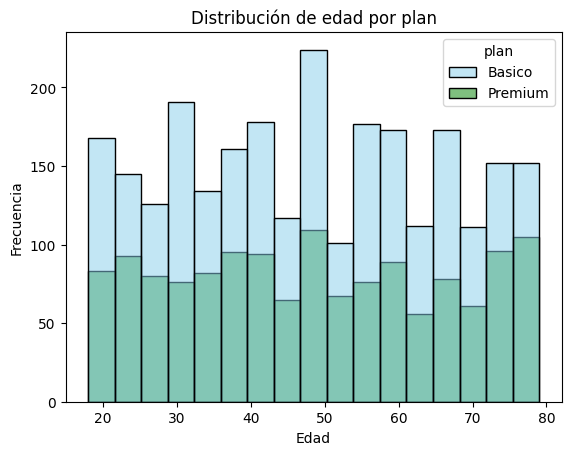

In [30]:

# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

Distribución de edad: Las edades de los usuarios se encuentran distribuidas a lo largo de todo el rango observado, entre 18 y 79 años, sin mostrar un sesgo marcado hacia edades menores o mayores. 

Ambos planes presentan usuarios en prácticamente todos los rangos de edad y no se observa visualmente un patrón claramente diferenciado de edad según el plan. 

El plan Básico presenta frecuencias mayores en general, lo cual es consistente con su mayor participación en la base de clientes (64.875% frente a 35.125% del plan Premium).

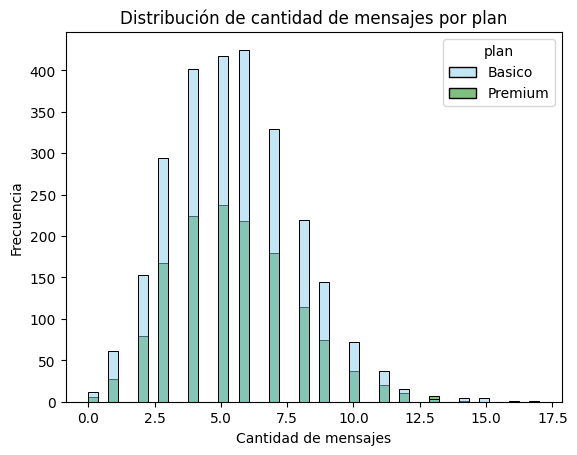

In [31]:

# Histograma para visualizar la cantidad de mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de cantidad de mensajes por plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

Distribución de cantidad de mensajes: La mayor concentración de usuarios se encuentra aproximadamente entre 4 y 7 mensajes, tanto para el plan Básico como para el plan Premium. 

La distribución presenta un ligero sesgo hacia la derecha, debido a la presencia de una menor cantidad de usuarios con valores elevados de mensajes, llegando hasta 17. 

Ambos planes muestran un patrón de distribución similar, sin observarse visualmente una diferencia marcada en el comportamiento de mensajería. 

Las mayores frecuencias absolutas del plan Básico son consistentes con su mayor número de usuarios en la base.

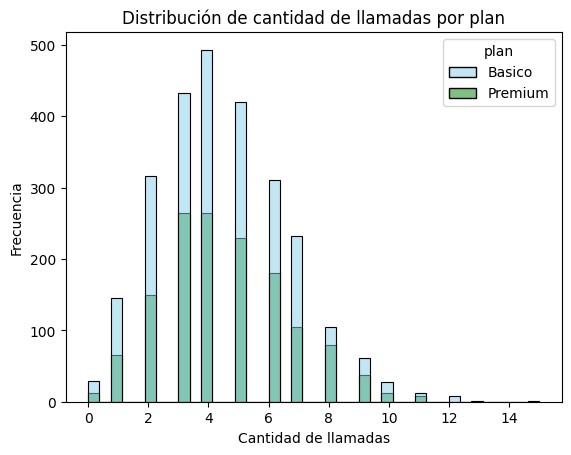

In [32]:

# Histograma para visualizar la cantidad de llamadas
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de cantidad de llamadas por plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

Distribución de cantidad de llamadas: La mayor concentración de usuarios se encuentra aproximadamente entre 3 y 6 llamadas, con un pico cercano a 4 llamadas. 

La distribución presenta un ligero sesgo hacia la derecha, debido a una menor cantidad de usuarios con números elevados de llamadas, alcanzando un máximo de 15. 

Los planes Básico y Premium muestran un patrón de distribución similar, sin observarse visualmente una diferencia marcada en el comportamiento de llamadas. 

Las mayores frecuencias absolutas del plan Básico son consistentes con su mayor participación en la base de clientes.

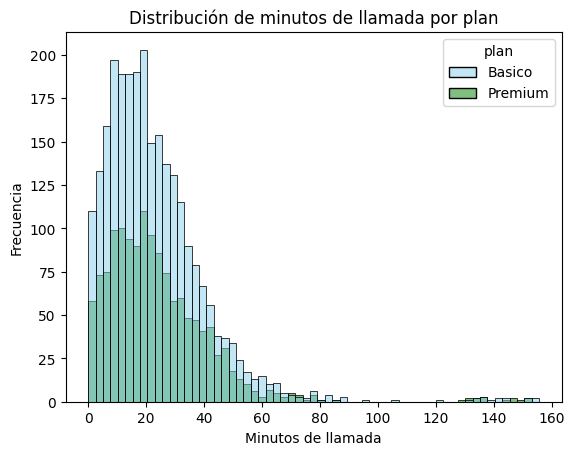

In [33]:

# Histograma para visualizar los minutos de llamada
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green']
)

plt.title('Distribución de minutos de llamada por plan')
plt.xlabel('Minutos de llamada')
plt.ylabel('Frecuencia')
plt.show()

💡Insights: 

Distribución de minutos de llamada: La mayor concentración de usuarios se encuentra en valores relativamente bajos de minutos de llamada, aproximadamente entre 5 y 40 minutos. 

La distribución presenta un claro sesgo hacia la derecha, con una cola prolongada formada por usuarios con consumos considerablemente mayores y un máximo de 155.69 minutos. 

Los planes Básico y Premium muestran un patrón general similar, con concentración en los valores bajos y disminución de la frecuencia conforme aumentan los minutos. 

También se observan valores elevados en ambos planes, por lo que conviene analizarlos posteriormente como posibles outliers.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

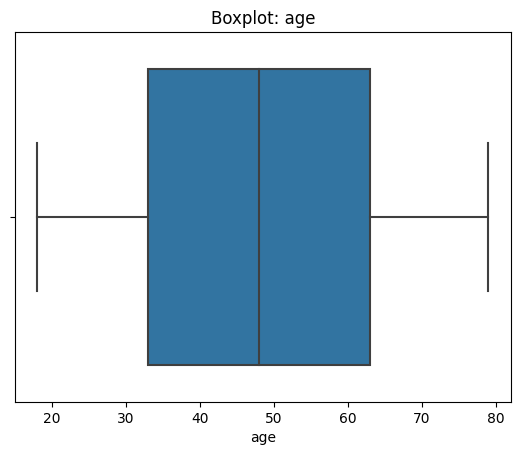

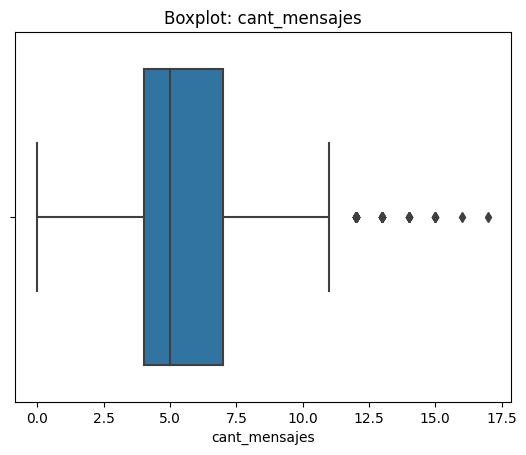

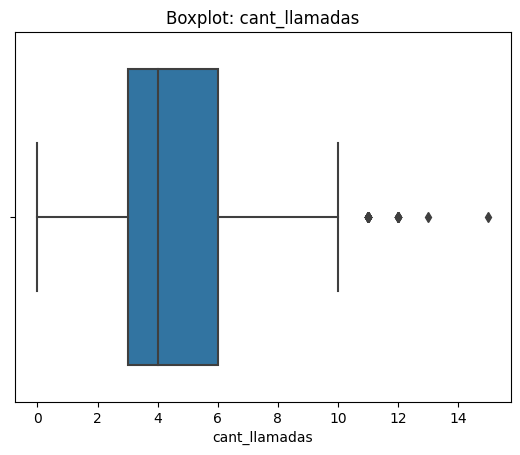

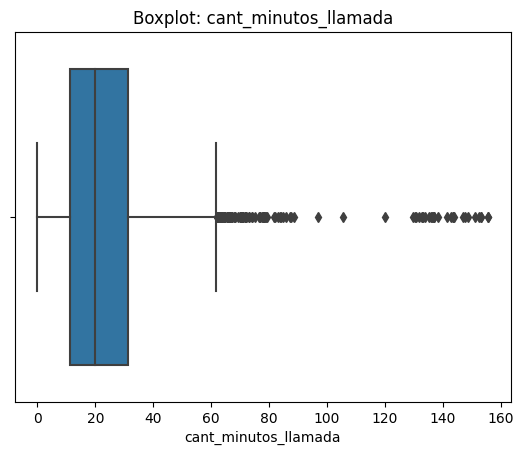

In [34]:

# Visualizando usando BoxPlot
columnas_numericas = [
    'age',
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_numericas:
    sns.boxplot(
        data=user_profile,
        x=col
    )
    
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

💡Insights: 

Age: No presenta valores atípicos visibles; las edades observadas se encuentran dentro de los límites del boxplot.

Cant_mensajes: Presenta valores atípicos en el extremo superior de la distribución.

Cant_llamadas: Presenta valores atípicos en el extremo superior de la distribución.

Cant_minutos_llamada: Presenta múltiples valores atípicos en el extremo superior, algunos considerablemente alejados del resto de la distribución.

In [35]:

# Calcular límites con el método IQR
columnas_limites = [
    'cant_mensajes',
    'cant_llamadas',
    'cant_minutos_llamada'
]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR

    print(f'{col}:')
    print(f'Límite superior: {limite_superior}')
    print()

cant_mensajes:
Límite superior: 11.5

cant_llamadas:
Límite superior: 10.5

cant_minutos_llamada:
Límite superior: 61.8575



In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 

cant_mensajes: mantener o no outliers, porqué?

El límite superior calculado mediante IQR es 11.5, mientras que el máximo observado es 17, por lo que existen outliers superiores a partir de 12 mensajes. Se decide mantenerlos, ya que representan cantidades de uso plausibles y no existe evidencia de que correspondan a errores de registro.

cant_llamadas: mantener o no outliers, porqué?

El límite superior es 10.5 y el máximo observado es 15, por lo que existen outliers superiores a partir de 11 llamadas. Se mantienen porque pueden representar usuarios con mayor actividad y no se identificó evidencia de valores inválidos.

cant_minutos_llamada: mantener o no outliers, porqué?

cant_minutos_llamada: el límite superior es 61.8575 minutos y el máximo alcanza 155.69 minutos. Aunque existen valores considerablemente alejados de la distribución principal, se mantienen porque pueden corresponder a usuarios con un consumo intensivo real. Además, estos comportamientos atípicos son relevantes para los objetivos del análisis y podrían representar oportunidades de segmentación comercial.

age: no presenta outliers según el boxplot, por lo que no requiere tratamiento adicional.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:
import numpy as np

In [38]:

# Crear columna grupo_uso
condiciones_uso = [
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
]

grupos_uso = ['Bajo uso', 'Uso medio']

user_profile['grupo_uso'] = np.select(
    condiciones_uso,
    grupos_uso,
    default='Alto uso'
)

In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [40]:

# Crear columna grupo_edad
condiciones_edad = [
    user_profile['age'] < 30,
    user_profile['age'] < 60
]

grupos_edad = ['Joven', 'Adulto']

user_profile['grupo_edad'] = np.select(
    condiciones_edad,
    grupos_edad,
    default='Adulto Mayor'
)


In [41]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

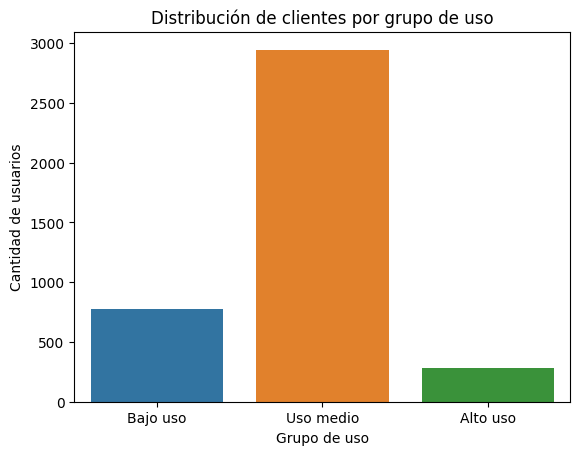

In [42]:

# Visualización de los segmentos por uso

sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso']
)

plt.title('Distribución de clientes por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [43]:
user_profile['grupo_uso'].value_counts()

Uso medio    2943
Bajo uso      778
Alto uso      279
Name: grupo_uso, dtype: int64

💡 Insight — Segmentación por uso.

Distribución por grupo de uso: El segmento predominante es Uso medio, con 2,943 usuarios (73.58% del total). Le sigue Bajo uso, con 778 usuarios (19.45%), mientras que Alto uso representa el grupo más pequeño, con 279 usuarios (6.98%). Esto indica que la mayor parte de los clientes presenta un nivel intermedio de actividad según los criterios definidos de llamadas y mensajes, mientras que una proporción relativamente pequeña pertenece al segmento de uso alto.

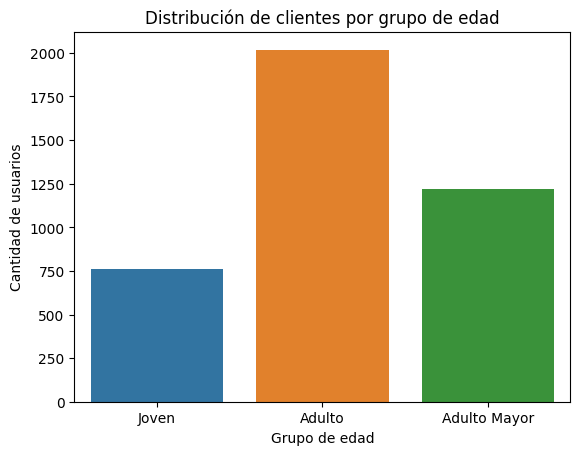

In [44]:
# Visualización de los segmentos por edad

sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor']
)

plt.title('Distribución de clientes por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [45]:
user_profile['grupo_edad'].value_counts()

Adulto          2018
Adulto Mayor    1222
Joven            760
Name: grupo_edad, dtype: int64

💡 Insight — Segmentación por edad.

Distribución por grupo de edad: El grupo Adulto es el más numeroso, con 2,018 usuarios (50.45% del total). Le sigue Adulto Mayor, con 1,222 usuarios (30.55%), mientras que Joven representa 760 usuarios (19.00%). Por lo tanto, poco más de la mitad de la base de clientes se concentra en el segmento de 30 a 59 años definido como Adulto.


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**

En users, la columna city contenía 469 valores nulos (11.73%) y 96 registros con el sentinel "?" (2.40%). Al unificar ambos casos como datos faltantes, se obtuvieron 565 usuarios sin ciudad válida (14.13% del total).

En age se detectaron valores sentinel de -999, incompatibles con una edad válida. Estos registros se corrigieron utilizando la mediana calculada sobre las edades válidas, obteniendo posteriormente un rango de 18 a 79 años.

En reg_date se encontraron 40 registros correspondientes a 2026 (1.00% de los usuarios). Debido a que los datos disponibles llegan únicamente hasta 2024, estas fechas fueron consideradas fuera de rango y se transformaron en valores nulos.

En usage, date contenía 50 valores nulos de 40,000 registros (0.125%). No se imputaron fechas arbitrarias.

duration presentaba 22,076 valores nulos (55.19%) y length 17,896 (44.74%). Se comprobó que estos faltantes dependen principalmente del tipo de evento: duration corresponde a llamadas y length a mensajes. Por ello, estos valores se conservaron como nulos en lugar de imputarlos. También se detectaron pequeñas inconsistencias: 16 registros de texto contenían duración y 12 registros de llamada contenían longitud.

churn_date presenta 3,534 valores nulos (88.35%). Debido a que esta variable puede representar la ausencia de una fecha de baja, no se trató automáticamente como un error ni se imputó.

🔍 **Segmentos por Edad**

Se identificaron tres segmentos: Joven (<30 años), Adulto (30–59 años) y Adulto Mayor (60 años o más).

El segmento Adulto concentra 2,018 usuarios (50.45%), seguido por Adulto Mayor, con 1,222 (30.55%), y Joven, con 760 (19.00%).

Por lo tanto, 81% de la base tiene 30 años o más, mostrando que la cartera analizada está concentrada principalmente en clientes adultos y adultos mayores.

El análisis realizado permite conocer el tamaño de estos segmentos, pero no demuestra por sí solo que un grupo de edad consuma más que otro; para establecerlo sería necesario comparar directamente las métricas de uso por grupo_edad.

📊 **Segmentos por Nivel de Uso**

Se identificaron tres segmentos a partir de la cantidad de llamadas y mensajes: Bajo uso, Uso medio y Alto uso.

Uso medio es el segmento dominante, con 2,943 usuarios (73.58%). Bajo uso representa 778 usuarios (19.45%), mientras que Alto uso concentra 279 (6.98%).

Esto indica que la mayor parte de la cartera presenta un comportamiento intermedio según los umbrales establecidos, mientras que existe un grupo reducido de usuarios con niveles particularmente altos de actividad.

La base también está compuesta mayoritariamente por clientes del plan Básico (64.875%), frente a 35.125% del plan Premium. Sin embargo, la distribución de los histogramas no mostró diferencias visuales marcadas entre ambos planes en edad, mensajes o llamadas.

📈 **Patrones de uso extremo y oportunidades**

Se detectaron outliers superiores en las tres métricas de uso. Para cant_mensajes, el límite IQR fue 11.5 frente a un máximo de 17 mensajes; para cant_llamadas, 10.5 frente a un máximo de 15 llamadas; y para cant_minutos_llamada, 61.8575 minutos frente a un máximo de 155.69 minutos.

Los minutos de llamada presentan el comportamiento extremo más pronunciado y una clara distribución sesgada hacia la derecha.

Estos valores se conservaron porque, aunque son estadísticamente atípicos, son plausibles como comportamientos reales de clientes intensivos y no existe evidencia suficiente para clasificarlos como errores.

Desde una perspectiva comercial, estos usuarios son especialmente interesantes para investigar: un consumo elevado puede señalar necesidades distintas a las del cliente promedio y oportunidades de migración, personalización o creación de ofertas específicas.

➡️ Esto sugiere que ConnectaTel posee una base dominada por clientes de uso medio y por usuarios de 30 años o más, junto con un grupo reducido de clientes de uso intensivo. 

Los datos muestran oportunidades para desarrollar ofertas diferenciadas según intensidad de uso, aunque antes de asociarlas específicamente con edad o plan, convendría analizar conjuntamente esas variables.

💡 **Recomendaciones**

Diseñar o evaluar una oferta intermedia orientada al segmento Uso medio, ya que representa aproximadamente tres de cada cuatro usuarios de la base.

Analizar individualmente el segmento Alto uso y los clientes que superan los límites IQR, especialmente en minutos de llamada, para evaluar posibles beneficios por alto consumo, paquetes adicionales o migración hacia planes con mayores capacidades.

Investigar el segmento Bajo uso para determinar si su menor actividad responde a necesidades naturalmente reducidas o a una baja utilización del servicio; esto permitiría evaluar ofertas más simples y acciones de retención sin asumir que el bajo uso implica necesariamente insatisfacción.

Profundizar el cruce entre grupo_edad, grupo_uso y plan antes de diseñar campañas dirigidas por edad. El análisis actual muestra el tamaño de cada segmento, pero no permite concluir todavía que determinados grupos etarios tengan mayor consumo.

Mejorar los controles de calidad en la captura de city, fechas y variables asociadas al tipo de evento, reduciendo sentinels, fechas fuera de rango y registros inconsistentes que pueden afectar futuras decisiones comerciales.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

https://github.com/sergioyepeztapia-jpg/ConnectaTel_Customer_Analysis_Sprint7_Final_Project